In [2]:
import pandas as pd

In [59]:
df = pd.read_csv("bhp.csv")
df

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250
...,...,...,...,...,...,...,...
13195,Whitefield,5 Bedroom,3453.0,4.0,231.00,5,6689
13196,other,4 BHK,3600.0,5.0,400.00,4,11111
13197,Raja Rajeshwari Nagar,2 BHK,1141.0,2.0,60.00,2,5258
13198,Padmanabhanagar,4 BHK,4689.0,4.0,488.00,4,10407


In [60]:
import seaborn as sns

In [61]:
lower = df["price_per_sqft"].quantile(0.001)
higher= df["price_per_sqft"].quantile(0.999)

df_step1 = df[(df["price_per_sqft"]>=lower) & (df["price_per_sqft"]<=higher)]
df_step1

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250
...,...,...,...,...,...,...,...
13195,Whitefield,5 Bedroom,3453.0,4.0,231.00,5,6689
13196,other,4 BHK,3600.0,5.0,400.00,4,11111
13197,Raja Rajeshwari Nagar,2 BHK,1141.0,2.0,60.00,2,5258
13198,Padmanabhanagar,4 BHK,4689.0,4.0,488.00,4,10407


In [67]:
max_limit = df_step1.price_per_sqft.mean() + 4*df_step1.price_per_sqft.std()
min_limit = df_step1.price_per_sqft.mean() - 4*df_step1.price_per_sqft.std()
max_limit, min_limit

(np.float64(23227.73653589432), np.float64(-9900.429065502578))

In [63]:
mean = df.price_per_sqft.mean()
mean

np.float64(7920.336742424242)

In [64]:
mean-4*std_deviation

np.float64(-8643.746058274206)

In [65]:
mean+4*std_deviation

np.float64(24484.41954312269)

In [68]:
df_step2 = df_step1[(df_step1.price_per_sqft>min_limit) & (df_step1.price_per_sqft<max_limit)]
df_step2.shape

(13047, 7)

In [37]:
import matplotlib.pyplot as plt

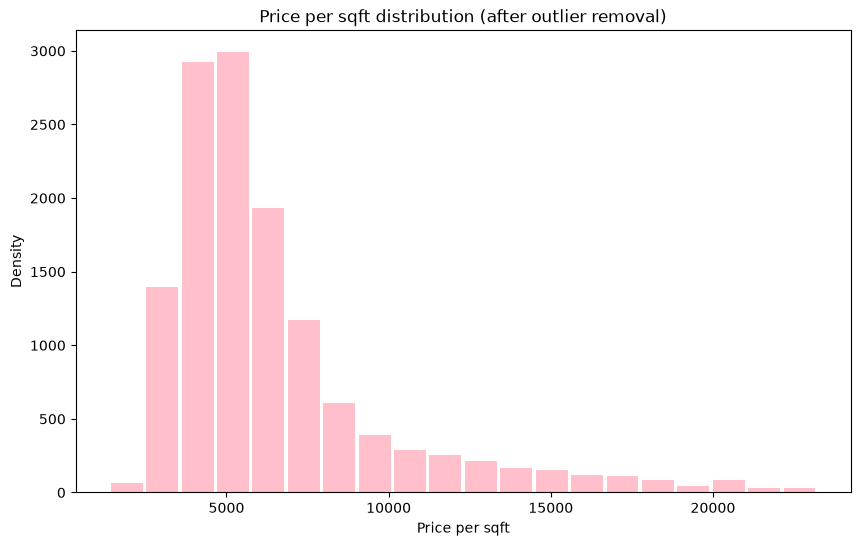

In [74]:
plt.figure(figsize=(10,6))
plt.hist(x =df_step2.price_per_sqft, bins=20,rwidth=0.9, color="pink")
plt.title("Price per sqft distribution (after outlier removal)")
plt.xlabel("Price per sqft")
plt.ylabel("Density")
plt.show()